# [Video RAG] VectorDB Indexing

In [1]:
%pip install -Uqqq langchain langchain-openai langchain-pinecone langchain-text-splitters

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.8/125.8 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.8/571.8 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.6/587.6 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.3/259.3 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 5.8 MB/s eta 0:00:00


In [2]:
# 구글 드라이브 마운트 및 연동
from google.colab import drive  # Colab에서 구글드라이브 사용 모듈
drive.mount('/content/drive')   # 현재 런타임에서 내 구글드라이브 마운트(연동)

BASE_PATH = '/content/drive/MyDrive/SK네트웍스 Family AI 캠프 34기/05_multimodal_rag'

Mounted at /content/drive


In [3]:
import os
from google.colab import userdata

os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://apac.api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = userdata.get('LANGSMITH_API_KEY')
os.environ['PINECONE_API_KEY'] = userdata.get('PINECONE_API_KEY')

## 비디오별 caption 불러오기
- BASE_PATH/captions/{video_name}_frames.csv

In [5]:
captions_dir_path = os.path.join(BASE_PATH, 'captions')  # captions 폴더 경로
# captions 폴더 내 파일들을 전체 경로 리스트로 변환
csv_files_path = [os.path.join(captions_dir_path, f) for f in os.listdir(captions_dir_path)]
csv_files_path

['/content/drive/MyDrive/SK네트웍스 Family AI 캠프 34기/05_multimodal_rag/captions/alpinist_frames.csv',
 '/content/drive/MyDrive/SK네트웍스 Family AI 캠프 34기/05_multimodal_rag/captions/skiing_frames.csv',
 '/content/drive/MyDrive/SK네트웍스 Family AI 캠프 34기/05_multimodal_rag/captions/baseball_frames.csv',
 '/content/drive/MyDrive/SK네트웍스 Family AI 캠프 34기/05_multimodal_rag/captions/basketball_frames.csv',
 '/content/drive/MyDrive/SK네트웍스 Family AI 캠프 34기/05_multimodal_rag/captions/soccer_frames.csv']

In [6]:
# 여러 캡션 CSV 로드 후 하나의 DataFrame으로 병합
import pandas as pd

dfs = []  # 각 CSV에서 읽은 DataFrames 리스트
for f in csv_files_path:
    df = pd.read_csv(f)  # CSV -> DataFrame 로드
    print(f"{os.path.basename(f)}: {df.shape = }")
    dfs.append(df)

# 모든 DataFrame을 행 방향으로 합침 (인덱스 재부여)
all_df = pd.concat(dfs, ignore_index=True)
print(all_df.shape)
all_df.head(20)

alpinist_frames.csv: df.shape = (23, 4)
skiing_frames.csv: df.shape = (12, 4)
baseball_frames.csv: df.shape = (25, 4)
basketball_frames.csv: df.shape = (14, 4)
soccer_frames.csv: df.shape = (12, 4)
(86, 4)


,id,video_filename,frame_no,description
0,1f0c3958-4035-4972-81e1-eec22ee86f14,alpinist.mp4,0,"등산객이 주황색 패딩과 배낭을 착용하고, 스틱을 짚으며 눈 덮인 가파른 산길을 오르..."
1,99d6d432-f041-4724-a859-4e64560d4c4a,alpinist.mp4,30,등산객이 주황색 재킷과 배낭을 착용하고 아이젠과 등산 스틱을 이용해 눈 덮인 가파른...
2,d0eff558-adbc-44c0-8f3a-482fc6626a64,alpinist.mp4,60,"등산객이 주황색 재킷과 배낭을 착용하고, 스틱을 짚으며 눈 덮인 가파른 산길을 오르..."
3,a7918a0a-a66a-466a-b31d-d8ce81f0af8e,alpinist.mp4,90,등산객이 주황색 재킷과 배낭을 착용하고 등산 스틱을 사용해 눈 덮인 가파른 산길을 ...
4,aa825f80-99ab-4901-b973-c9da470cff69,alpinist.mp4,120,등산객이 주황색 재킷과 배낭을 착용하고 스틱과 아이젠을 이용해 눈 덮인 험준한 산길...
5,adc941d7-c4a8-486b-adfe-218ddad49fdf,alpinist.mp4,150,등산객이 아이젠을 착용하고 스틱을 짚으며 눈 덮인 험준한 산길을 오르고 있습니다. ...
6,e3d450b6-4af7-41a8-adb1-ae2378bce7b0,alpinist.mp4,180,등산객이 아이젠과 스틱을 사용해 눈 덮인 가파른 바위 능선을 오르고 있습니다. 오른...
7,c5c3152a-b98f-4e08-b279-a986019cf909,alpinist.mp4,210,눈 덮인 험준한 산길에서 주황색 재킷을 입은 등산객이 트레킹 폴을 사용해 바위 사이...
8,b0e8e96d-d7b1-49c0-bfc7-224ba57b7947,alpinist.mp4,240,한 등산객이 주황색 재킷과 배낭을 착용하고 스틱을 사용해 눈 덮인 가파른 바위 능선...
9,5c357126-cc9e-4481-92ea-243beae7c3dd,alpinist.mp4,270,"한 등산객이 주황색 재킷과 아이젠, 등산 스틱을 착용하고 눈 덮인 가파른 바위 능선..."


## chunking

In [8]:
from langchain_text_splitters import RecursiveCharacterTextSplitter  # Langchain 청크 분할기
from tqdm import tqdm
import uuid  # 고유 ID 생성

# tiktoken 기준(모델 토큰화 방식)으로 분할기 객체 생성
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    model_name = 'gpt-5.6-luna',  # 토큰 인코딩 기준 모델
    chunk_size = 300,             # 청크 목표 토큰 수
    chunk_overlap = 150,          # 청크 겹치는 토큰 수
    separators = ['\n\n', '\n', ' ', ''] # 분리 우선순위 (문단 -> 줄 -> 공백 -> 문자 단위)
)

In [9]:
# 프레임 캡션 텍스트를 청크로 분할해서 DataFrame 생성
chunks = []  # 분할된 청크들을 (dict) 형태로 누적할 리스트

for idx, row in tqdm(all_df.iterrows(), total=len(all_df)):
    frame_no = row['frame_no']
    video_filename = row['video_filename']
    description = row['description']

    # 여러 청크로 분할하여 청크단위로 순회
    for chunk in text_splitter.split_text(description):
        chunks.append({
            'id': str(uuid.uuid4()),  # 고유 ID 생성
            'frame_no': frame_no,
            'video_filename': video_filename,
            'description': chunk
        })

chunks_df = pd.DataFrame(chunks)
print(chunks_df.shape)  # 청크 데이터 (행, 열)
pd.set_option('display.max_colwidth', None)  # df이 잘리지않고 전체 보이도록 설정
chunks_df.head(10)

100%|██████████| 86/86 [00:00<00:00, 2583.14it/s]

(86, 4)


,id,frame_no,video_filename,description
0,078d2d89-be57-4191-b618-659d356cee30,0,alpinist.mp4,"등산객이 주황색 패딩과 배낭을 착용하고, 스틱을 짚으며 눈 덮인 가파른 산길을 오르고 있습니다. 오른쪽에는 높은 눈벽이, 왼쪽에는 바위산과 멀리 펼쳐진 풍경이 보입니다."
1,168735a3-0e6c-4e43-b7d8-3a773f1683da,30,alpinist.mp4,"등산객이 주황색 재킷과 배낭을 착용하고 아이젠과 등산 스틱을 이용해 눈 덮인 가파른 산길을 오르고 있다. 오른쪽에는 눈벽이, 왼쪽에는 바위 경사면과 산 아래 풍경이 보인다."
2,d8b3d7a2-11d5-4bfe-9788-9d6fdc148f63,60,alpinist.mp4,"등산객이 주황색 재킷과 배낭을 착용하고, 스틱을 짚으며 눈 덮인 가파른 산길을 오르고 있다. 오른쪽에는 높은 설벽이, 왼쪽에는 바위산과 산 아래 풍경이 보인다."
3,20bd7caf-92d0-4a5a-b72a-9c83bdf6f08a,90,alpinist.mp4,"등산객이 주황색 재킷과 배낭을 착용하고 등산 스틱을 사용해 눈 덮인 가파른 산길을 오르고 있다. 오른쪽에는 높은 눈벽이, 왼쪽에는 바위산과 산 아래 풍경이 펼쳐져 있다."
4,1d929f12-d409-4c07-b3ea-9af0ec70eac3,120,alpinist.mp4,"등산객이 주황색 재킷과 배낭을 착용하고 스틱과 아이젠을 이용해 눈 덮인 험준한 산길을 오르고 있다. 오른쪽에는 큰 설벽과 암벽이 있으며, 왼쪽으로는 산 아래 풍경이 펼쳐진다."
5,09f2c330-b996-4ae0-9e80-2d8e974e325d,150,alpinist.mp4,"등산객이 아이젠을 착용하고 스틱을 짚으며 눈 덮인 험준한 산길을 오르고 있습니다. 한쪽에는 가파른 바위 능선과 산 아래 풍경이, 다른 쪽에는 높은 눈벽이 보입니다."
6,b2159c54-21b7-49c8-876a-5d097f729096,180,alpinist.mp4,"등산객이 아이젠과 스틱을 사용해 눈 덮인 가파른 바위 능선을 오르고 있습니다. 오른쪽에는 높은 눈벽이 있고, 왼쪽으로는 산악 지형과 탁 트인 전망이 보입니다."
7,ae29b355-e463-4f3c-8289-e870dfb57bc5,210,alpinist.mp4,"눈 덮인 험준한 산길에서 주황색 재킷을 입은 등산객이 트레킹 폴을 사용해 바위 사이를 오르고 있다. 오른쪽에는 높은 눈벽이 있고, 왼쪽으로는 가파른 산비탈과 먼 풍경이 보인다."
8,d175dbc8-fa60-4c38-b273-0d70aecfbed1,240,alpinist.mp4,"한 등산객이 주황색 재킷과 배낭을 착용하고 스틱을 사용해 눈 덮인 가파른 바위 능선을 오르고 있다. 오른쪽에는 큰 눈벽이 있고, 왼쪽으로는 산악 지형과 먼 풍경이 펼쳐져 있다."
9,ac35f48f-614d-4a57-b23c-c8b0430fdf6a,270,alpinist.mp4,"한 등산객이 주황색 재킷과 아이젠, 등산 스틱을 착용하고 눈 덮인 가파른 바위 능선을 오르고 있습니다. 주변에는 두꺼운 눈벽과 암벽이 있으며, 왼쪽으로 산 아래 풍경이 펼쳐집니다."


In [10]:
# 프레임(비디오+프레임번호)별 청크 개수 집계
chunks_df[['video_filename', 'frame_no']].value_counts().sort_index()

video_filename  frame_no
alpinist.mp4    0           1
                30          1
                60          1
                90          1
                120         1
                           ..
soccer.mp4      210         1
                240         1
                270         1
                300         1
                330         1
Name: count, Length: 86, dtype: int64

## Indexing

In [11]:
from pinecone import Pinecone, ServerlessSpec

pc = Pinecone()
PINECONE_INDEX_NAME = 'video-caption-kr'
index_list = [index.name for index in pc.list_indexes()]  # 현재 계정의 인덱스 이름 리스트

if PINECONE_INDEX_NAME not in index_list:
    pc.create_index(
        name = PINECONE_INDEX_NAME,
        dimension = 1536,
        metric = 'cosine',
        # 클라우드 설정
        spec = ServerlessSpec(
            cloud = 'aws',
            region = 'us-east-1'
        )
    )
    print(f"{PINECONE_INDEX_NAME} 인덱스 생성 완료!")
else:
    print(f"{PINECONE_INDEX_NAME} 인덱스가 이미 존재함!")

video-caption-kr 인덱스 생성 완료!


In [12]:
# OpenAI 임베딩 모델 설정 / 벡터스토어 연결
from langchain_openai import OpenAIEmbeddings       # OpenAI 임베딩 생성기 (텍스트 -> 벡터)
from langchain_pinecone import PineconeVectorStore  # Langchain에서 Pinecone 벡터스토어 사용

embeddings = OpenAIEmbeddings(model='text-embedding-3-small')  # 인덱스 dimension과 동일한 차원의 임베딩모델
# 벡터스토어 구성
vector_store = PineconeVectorStore(
    index_name = PINECONE_INDEX_NAME,
    embedding = embeddings
)

In [13]:
texts = chunks_df['description'].tolist()  # 청크 텍스트 description 리스트
metadatas = [
    {
        'id': row['id'],
        'frame_no': row['frame_no'],
        'video_filename': row['video_filename']
    }
        for idx, row in chunks_df.iterrows()  # 데이터프레임 행별로 순회하면서
]

batch_size = 50

# 전체 텍스트를 batch_size 단위로 반복 순회하면서
for i in tqdm(range(0, len(texts), batch_size)):
    batch_text = texts[i: i + batch_size]          # 현재 배치의 텍스트 슬라이싱
    batch_metadata = metadatas[i: i + batch_size]  # 현재 배치의 메타데이터 슬라이싱
    vector_store.add_texts(batch_text, batch_metadata)  # 텍스트 임베딩하여 Pinecone 업서트

100%|██████████| 2/2 [00:07<00:00,  3.69s/it]


In [14]:
query = '농구공으로 드리블하면서 상대방을 제치는 장면'

results = vector_store.similarity_search(query, k=3)  # query와 가장 유사한 청크 3개 벡터 검색
results

[Document(id='9ab3f3ee-9bb9-4fdf-b7ee-e32506e435e5', metadata={'frame_no': 90.0, 'id': 'db8d1d84-24fb-4337-9ce8-d0edeb3b2b90', 'video_filename': 'basketball.mp4'}, page_content='야외 농구장에서 여러 사람이 농구공을 들고 움직이고 있다. 중앙의 선수가 검은 상의와 빨간 반바지를 입고 드리블하며, 주변 선수들은 수비 자세를 취하고 있다. 배경에는 농구 골대와 나무, 건물이 보인다.'),
 Document(id='3be59391-b091-48e0-897d-69ea2c0f8b57', metadata={'frame_no': 390.0, 'id': '8997e4fa-bb64-4cfd-b3d6-03e3398d7b3d', 'video_filename': 'basketball.mp4'}, page_content='야외 농구장에서 검은 상의와 빨간 반바지를 입은 사람이 농구공을 들고 달리고 있으며, 뒤쪽에는 흰옷을 입은 사람이 따라오고 있습니다. 주변에는 철제 펜스와 나무, 농구 골대가 보입니다.'),
 Document(id='885a3762-6b48-42fd-af44-c6bda19b1eef', metadata={'frame_no': 30.0, 'id': 'dfb200e5-15c1-4155-a9a2-388d85890823', 'video_filename': 'basketball.mp4'}, page_content='야외 코트에서 여러 사람이 농구를 하고 있다. 전경의 선수가 공을 드리블하며 움직이고, 뒤에는 농구 골대와 철조망이 보인다.')]

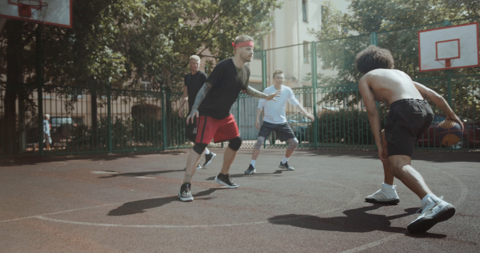

In [15]:
# 검색 결과 메타데이터로 원본 프레임 이미지 표시
from PIL import Image
import os

# 검색 결과 메타데이터를 기반으로 해당 프레임 이미지를 찾아 화면에 표시해주는 함수
def show_image_from_metadata(metadata, frame_dir='frames'):
    video_filename = metadata['video_filename']
    video_basename = os.path.splitext(video_filename)[0]  # 확장자 제거
    frame_no = int(metadata['frame_no'])

    image_filename = f'{video_basename}_frame{frame_no:05d}.jpg'  # 0 패딩 숫자 5자리 포함한 파일명
    image_path = os.path.join(BASE_PATH, frame_dir, video_basename, image_filename)  # 완성된 최종 경로

    image = Image.open(image_path)
    image.thumbnail((480, 270))
    display(image)

show_image_from_metadata(results[0].metadata)


[1]
야외 농구장에서 여러 사람이 농구공을 들고 움직이고 있다. 중앙의 선수가 검은 상의와 빨간 반바지를 입고 드리블하며, 주변 선수들은 수비 자세를 취하고 있다. 배경에는 농구 골대와 나무, 건물이 보인다.
{'frame_no': 90.0, 'id': 'db8d1d84-24fb-4337-9ce8-d0edeb3b2b90', 'video_filename': 'basketball.mp4'}


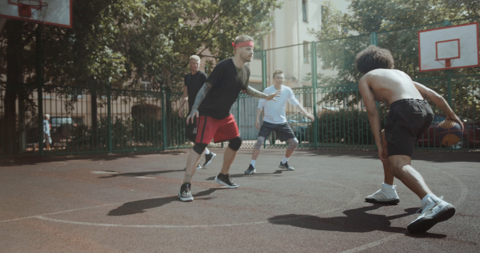

--------------------------------------------------
[2]
야외 농구장에서 검은 상의와 빨간 반바지를 입은 사람이 농구공을 들고 달리고 있으며, 뒤쪽에는 흰옷을 입은 사람이 따라오고 있습니다. 주변에는 철제 펜스와 나무, 농구 골대가 보입니다.
{'frame_no': 390.0, 'id': '8997e4fa-bb64-4cfd-b3d6-03e3398d7b3d', 'video_filename': 'basketball.mp4'}


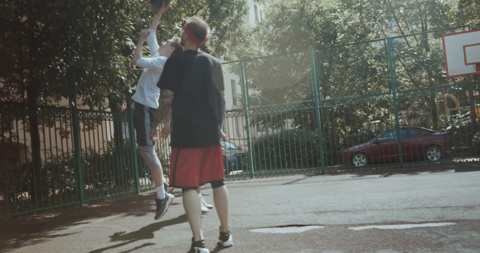

--------------------------------------------------
[3]
야외 코트에서 여러 사람이 농구를 하고 있다. 전경의 선수가 공을 드리블하며 움직이고, 뒤에는 농구 골대와 철조망이 보인다.
{'frame_no': 30.0, 'id': 'dfb200e5-15c1-4155-a9a2-388d85890823', 'video_filename': 'basketball.mp4'}


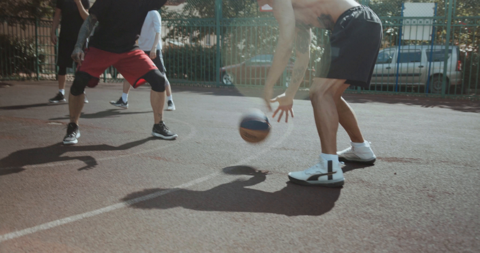

--------------------------------------------------


In [16]:
# 결과 모두 출력
for i, doc in enumerate(results):
    print(f"[{i + 1}]")
    print(doc.page_content)  # 본문 텍스트
    print(doc.metadata)      # 문서 메타데이터
    show_image_from_metadata(doc.metadata)  # 메타데이터 -> 이미지 표시
    print('-' * 50)